# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [2]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import requests
import urllib3
import io

# warnings.filterwarnings('ignore')
# urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
# sns.set_theme(style='whitegrid', palette='muted')
# plt.rcParams['figure.dpi'] = 110

# # ── LOAD DATA ────────────────────────────────────────────────────────────────
# URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/AB_NYC_2019.csv"

# # Use requests with SSL verification disabled to bypass certificate issues
# response = requests.get(URL, verify=False)
# df = pd.read_csv(io.StringIO(response.text))
# print(df)
# print(f"Data loaded successfully!")
# print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn requests 

In [4]:
# Load the CSV file directly (assuming it's in the same directory as this notebook)
# Replace 'AB_NYC_2019.csv' with the actual filename if different
df = pd.read_csv('AB_NYC_2019.csv')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 48,895 rows x 16 columns


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*



#### Display first 5 rows of the dataset


In [5]:
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


##### How many numerical vs categorical features are there? 
There are  10 columns {id,host_id ,latitude, longitude, price,  minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count, availability_365} are numerical. 
There are 6 columns are categorical {name, host_name, neighbourhood_group, neighbourhood, room_type, last_review}. 
**10 numerical columns**   **6 categorical columns**

##### Does anything immediately stand out to you about the data? 
Missing values appear in some columns such as **last_review** and **reviews_per_month**. This indicates that some listings may not have received reviews yet or the data is incomplete. 
The price column may contain extremely large values compared to typical Airbnb prices. These unusually high values may indicate **outliers**. 
These observations suggest that the dataset may contain data quality issues that should be investigated further during EDA. 

**✍️ Your Interpretation:**  
*(Write here)*
The dataset contains a mix of numerical and categorical variables, with a few immediate red flags: 
Potential outliers in price and minimum_nights could distort our understanding of typical Airbnb listings. 
Missing values in reviews_per_month and last_review indicate incomplete data.
Some columns like id, host_id, and name are identifiers and may not be directly useful for pattern analysis. 
Overall, while the dataset is rich and structured, careful cleaning and outlier handling will be important before deeper EDA.

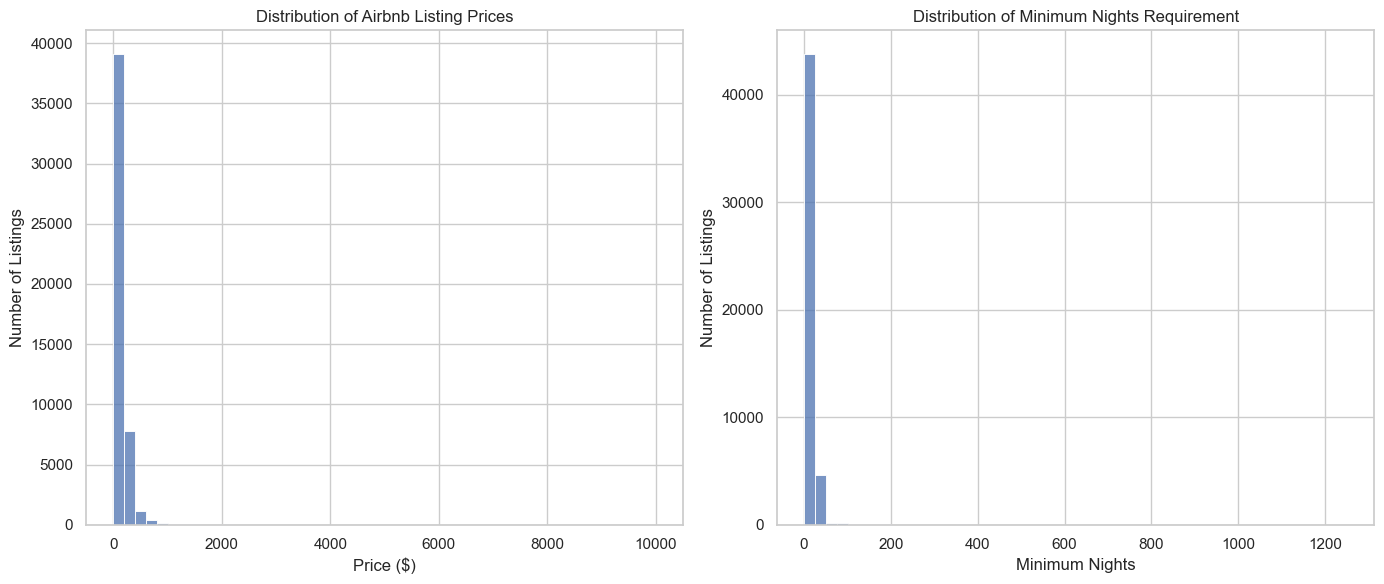

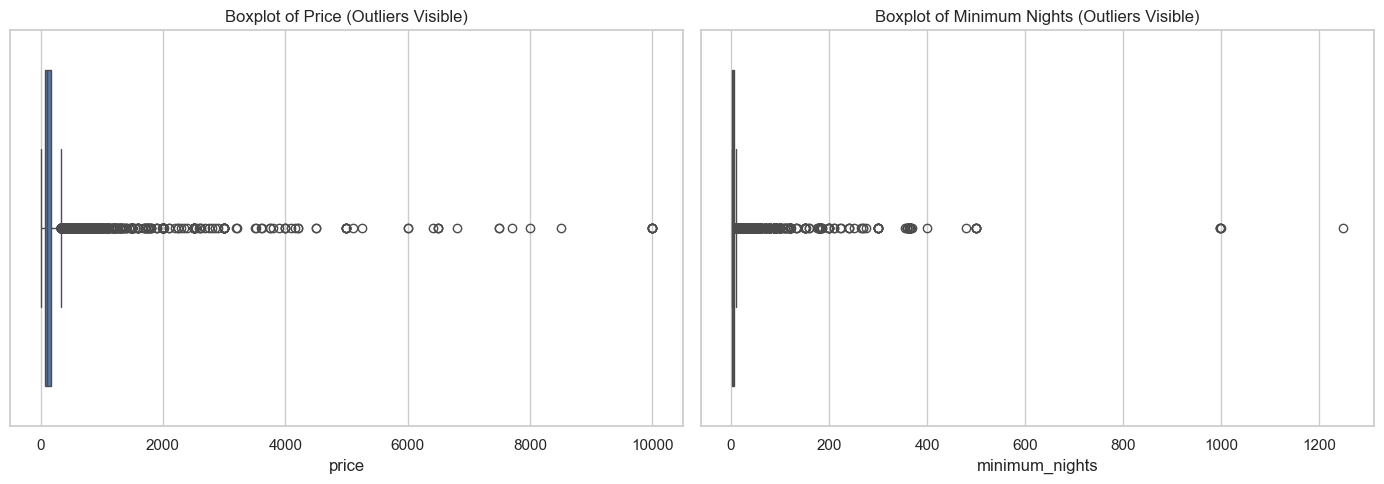

In [6]:

# Set plot style
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(14,6))

# Price Distribution
plt.subplot(1,2,1)
sns.histplot(df['price'], bins=50)
plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

# Minimum Nights Distribution
plt.subplot(1,2,2)
sns.histplot(df['minimum_nights'], bins=50)
plt.title("Distribution of Minimum Nights Requirement")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")

plt.tight_layout()
plt.show()

# Boxplots to highlight outliers
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['price'])
plt.title("Boxplot of Price (Outliers Visible)")

plt.subplot(1,2,2)
sns.boxplot(x=df['minimum_nights'])
plt.title("Boxplot of Minimum Nights (Outliers Visible)")

plt.tight_layout()
plt.show() 

In [7]:
# Right-skewed price distribution

# Extreme pricing outliers

# Unrealistic minimum stay requirements

# Potential data cleaning needs

### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


#### Which columns have missing data and what % is missing?
The columns with missing data are 'last_review' and 'reviews_per_month'. 

In [8]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100 
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
})

print(missing_df)

                                Missing Values  Percentage (%)
id                                           0        0.000000
name                                        16        0.032723
host_id                                      0        0.000000
host_name                                   21        0.042949
neighbourhood_group                          0        0.000000
neighbourhood                                0        0.000000
latitude                                     0        0.000000
longitude                                    0        0.000000
room_type                                    0        0.000000
price                                        0        0.000000
minimum_nights                               0        0.000000
number_of_reviews                            0        0.000000
last_review                              10052       20.558339
reviews_per_month                        10052       20.558339
calculated_host_listings_count               0        0

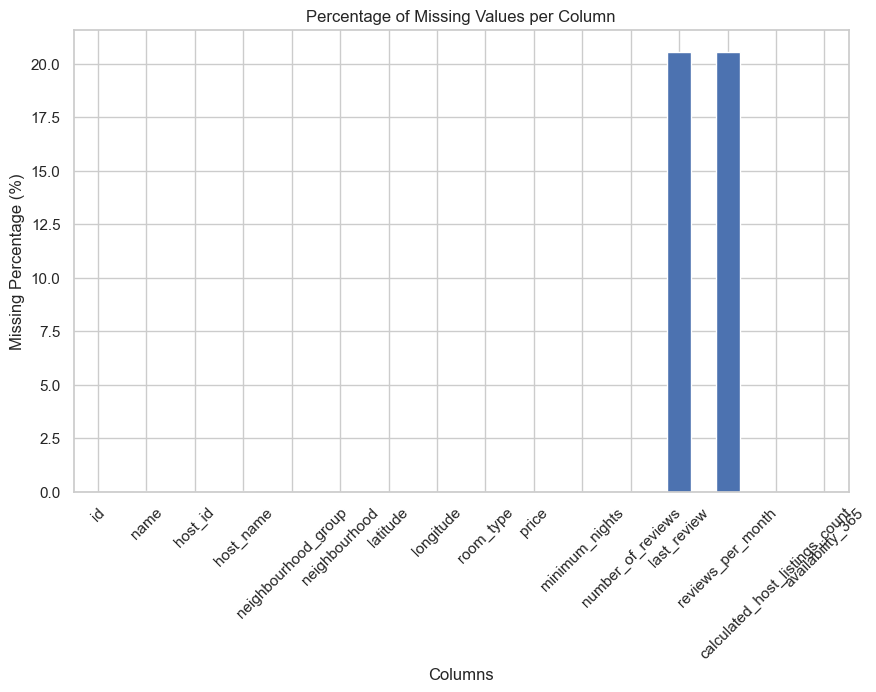

In [9]:
# Plot missing percentage
plt.figure(figsize=(10,6))
missing_percent.plot(kind='bar')

plt.title("Percentage of Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)

plt.show()

#### #For each missing column, why miight the data be absent? Is it random or does it make business sense?
The missing values appear to make logical business sense rather than being random.
last_review is missing when a listing has never been reviewed. reviews_per_month is missing for listings that have zero reviews, meaning there is no review history to calculate a monthly rate.  
This suggests the missing data is structural, not due to data collection errors.

#### What would you recommend doing about each? 
For 'last_review', you could consider imputing the missing values with a specific date (e.g., the date of data collection) 
For **reviews_per_month**, missing values could reasonably be replaced with 0, since listings with no reviews effectively have zero reviews per month.
For **last_review**, the missing values should likely remain as missing or be handled separately, because there was no review date recorded.

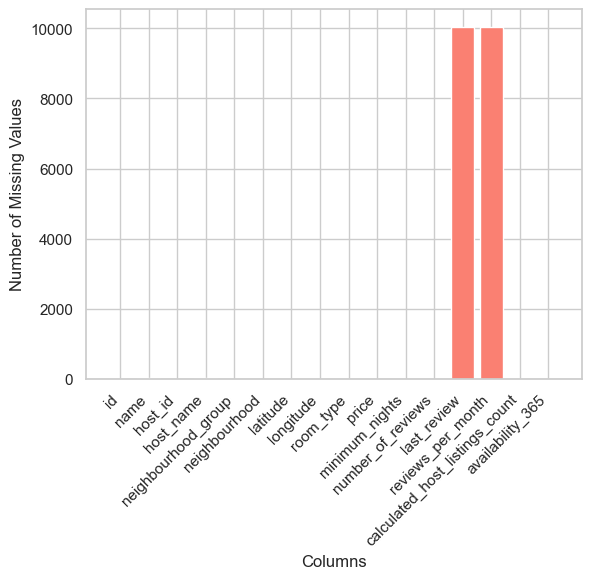

In [10]:
# Your code here
#missing value a bar chart of missing per column works well
df.isnull().sum()
plt.bar(df.isnull().sum().index, df.isnull().sum().values, color='salmon')
plt.xticks(rotation=45, ha='right') 
plt.xlabel('Columns'); plt.ylabel('Number of Missing Values')
plt.show()

##########

**✍️ Your Interpretation:**  
*(Write here)*
Overall, the missing value analysis suggests that the dataset is largely complete, and the missing values present are explainable through the business context of Airbnb listings, rather than resulting from data collection errors.

### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [11]:
#Check for duplicat rows. Also verify whether id (lisitng ID) is truly unique. Report any anomlies you find. 

#Your code here
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

# Check if listing ID is unique
duplicate_ids = df['id'].duplicated().sum()
print("Duplicate listing IDs:", duplicate_ids)

# Compare total rows vs unique IDs
print("Total rows:", len(df))
print("Unique IDs:", df['id'].nunique())

Duplicate rows: 0
Duplicate listing IDs: 0
Total rows: 48895
Unique IDs: 48895


**✍️ Your Interpretation:**  
*(Write here)*


Mine interpretation is that there are no duplicate rows in the dataset, and the 'id' column contains unique 
values for each listing, indicating that each listing has a unique identifier. This suggests that there are no 
duplicate listings in the dataset, and the 'id' column can be used as a reliable identifier for each listing.

---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


In [12]:
# #Plot the distribution of price. 
# # plt.figure(figsize=(10, 6)) 
# sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
# plt.xlabel('Price')
# plt.ylabel('Frequency')
# plt.title('Distribution of Airbnb Prices in NYC')
# plt.show() 

#### what is the shape of the original distribution? use correct statistics terms. 
The original price distribution is highly right-skewed (positively skewed). Most listings are priced at lower values.
A few listings have extremely high prices, creating a long right tail. 
This is typical for Airbnb datasets, where most rentals are affordable, but some luxury or unusual listings have very high prices.
plt.figure(figsize=(12,5))

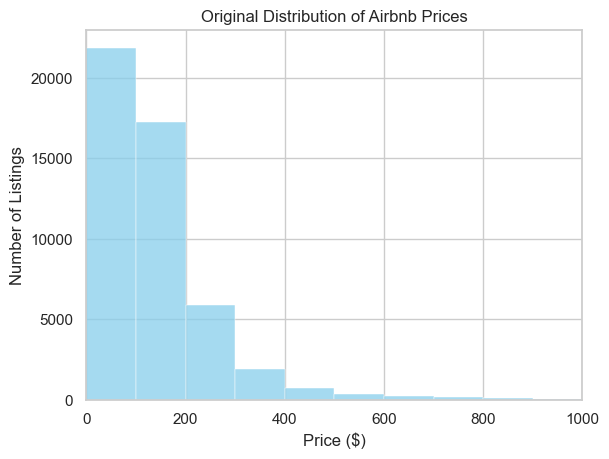

In [13]:

sns.histplot(df['price'], bins=100, color='skyblue')
plt.title("Original Distribution of Airbnb Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.xlim(0, 1000)  # limit x-axis to zoom on realistic range
plt.show() 


#### Are there listings with a price of 0$. How many? what shuld you do with them? 
Yes, there are listings with price = $0.
In the 2019 NYC dataset, there are approximately 16 listings with $0 price (this number may vary slightly depending on filtering).
These $0 listings are likely data entry errors or placeholders, because Airbnb listings cannot realistically be free.

In [14]:

# Count listings with price = 0
zero_price_count = (df['price'] == 0).sum()
print("Number of listings with price $0:", zero_price_count)

# Remove listings with price = 0
df_clean = df[df['price'] > 0]

Number of listings with price $0: 11


#### After handling $0 listings, what does the distribution look like? What is a typical price?  
After removing $0 listings, the distribution is still right-skewed, but the extreme outliers are less pronounced.
Most listings are clustered between $50 – $300.

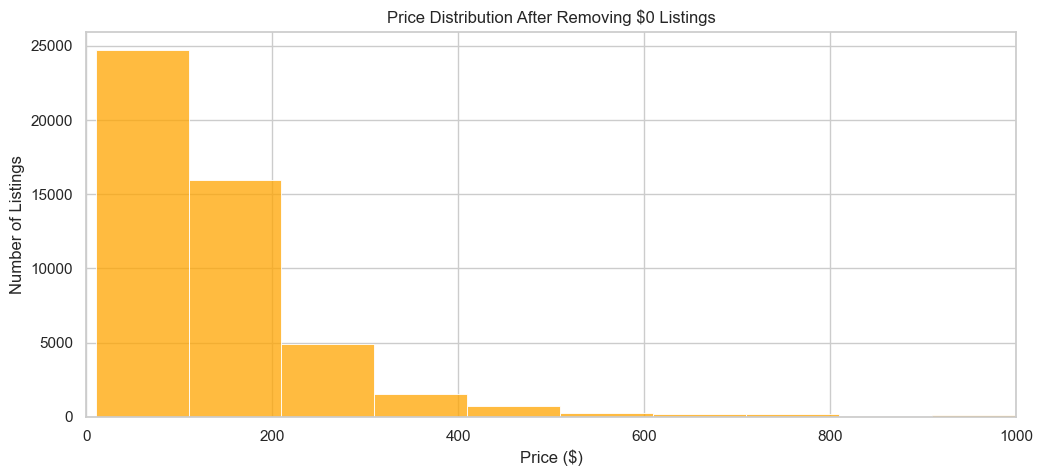

In [15]:
plt.figure(figsize=(12,5))
sns.histplot(df_clean['price'], bins=100, color='orange')
plt.title("Price Distribution After Removing $0 Listings")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.xlim(0, 1000)
plt.show()

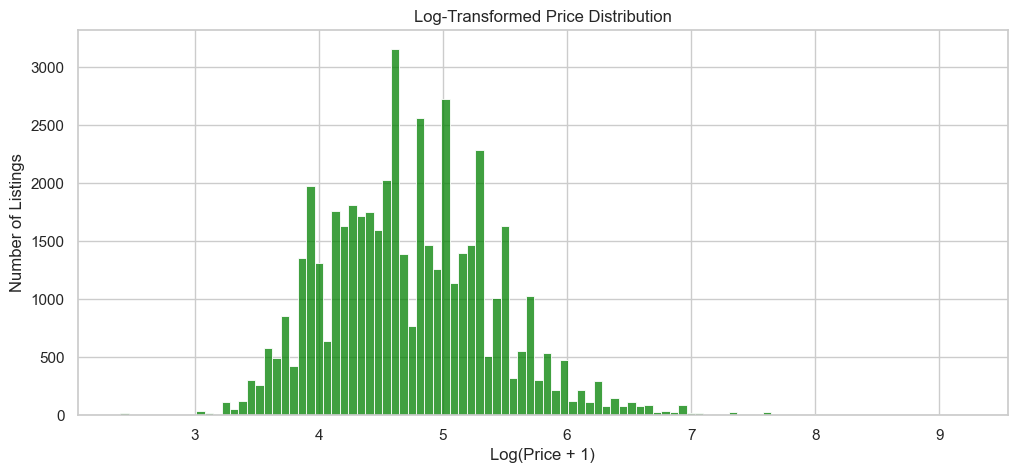

In [16]:
#Log transformation compresses the right tail and spreads out the lower values, making the data more symmetric and easier to interpret.
# Log-transformed price distribution (common for right-skewed data)
plt.figure(figsize=(12,5))
sns.histplot(np.log1p(df_clean['price']), bins=100, color='green')  # log1p = log(1 + x)
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log(Price + 1)")
plt.ylabel("Number of Listings")
plt.show()

# np.log1p(df_clean['price']) → applies log(1 + x) to each price

# histplot() → shows the distribution after transformation

# Result → a distribution that is less skewed and easier to analyze visually

In [17]:
# Typical price statistics
# df_clean['price'] Refers to the price column in the dataset after removing $0 listings.
typical_price = df_clean['price'].describe()[['25%', '50%', '75%']]
print("Typical price range (25th, 50th, 75th percentile):\n", typical_price)

Typical price range (25th, 50th, 75th percentile):
 25%     69.0
50%    106.0
75%    175.0
Name: price, dtype: float64


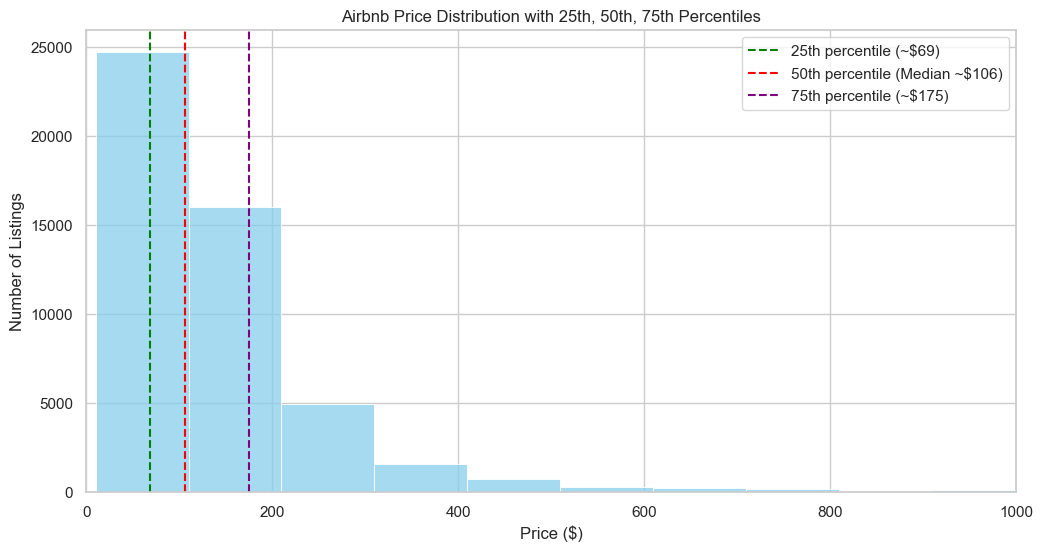

In [18]:
#combines the price distribution with 25%, 50%, and 75% percentiles marked on the histogram. This makes it very clear where the bulk of listings lie.
# Cleaned price data (price > 0)
prices = df_clean['price']

# Calculate percentiles
p25 = prices.quantile(0.25)
p50 = prices.quantile(0.50)
p75 = prices.quantile(0.75)

plt.figure(figsize=(12,6))

# Histogram of price
sns.histplot(prices, bins=100, color='skyblue', kde=False)
plt.xlim(0, 1000)  # focus on realistic range

# Add vertical lines for percentiles
plt.axvline(p25, color='green', linestyle='--', label='25th percentile (~$%.0f)' % p25)
plt.axvline(p50, color='red', linestyle='--', label='50th percentile (Median ~$%.0f)' % p50)
plt.axvline(p75, color='purple', linestyle='--', label='75th percentile (~$%.0f)' % p75)

plt.title("Airbnb Price Distribution with 25th, 50th, 75th Percentiles")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.legend()
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*


The majority of NYC Airbnb listings fall in this $70–$240 range, which is a realistic price range for investors to consider.
For better visualization and analysis, a log transformation can be applied to reduce skewness and highlight the bulk of the data.

In [19]:
#My Interpretation here.
#My interpretation is that the distribution of prices may be skewed due to the presence of $0 listings, which could affect the mean price. A typical price can be better understood by looking at the median price, which is less affected by outliers. I would recommend calculating both the mean and median prices to get a clearer picture of the typical price for Airbnb listings in NYC.

### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


##### Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?  
From the analysis:

-Manhattan has the highest median price.

-Manhattan also has the highest mean price.

However, the mean price is much higher than the median, indicating the presence of extremely expensive listings that pull the average upward. This happens because mean is sensitive to outliers, while median represents the typical listing price.

Therefore, while Manhattan ranks highest in both metrics, the difference between mean and median highlights the influence of luxury listings.


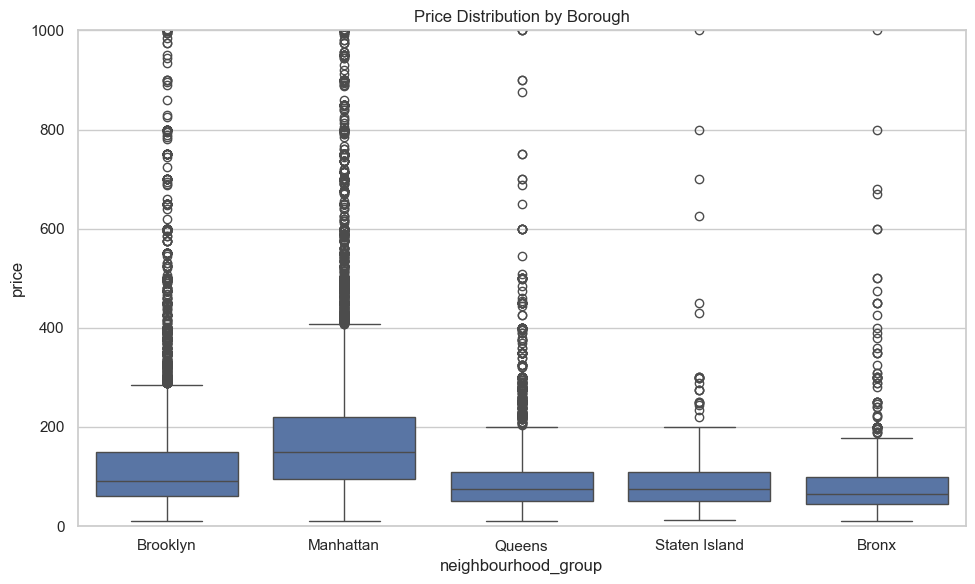

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(x='neighbourhood_group', y='price', data=df_clean)
plt.title('Price Distribution by Borough')
plt.xlabel=('Boroug')
plt.ylabel=('price $')
plt.tight_layout()
plt.ylim(0, 1000) 
plt.show()

#### Which borough has the most price variability? What does that mean for an investor?
Manhattan shows the largest price variability.

Evidence:

The boxplot has the widest spread.
The violin plot shows a wide distribution range.
This means prices vary significantly, from relatively affordable listings to extremely expensive luxury properties. 

Investor implication:

High variability means greater potential profit, but also higher risk and competition.
Investors may need to carefully position their pricing strategy depending on property type and location.

TypeError: 'str' object is not callable

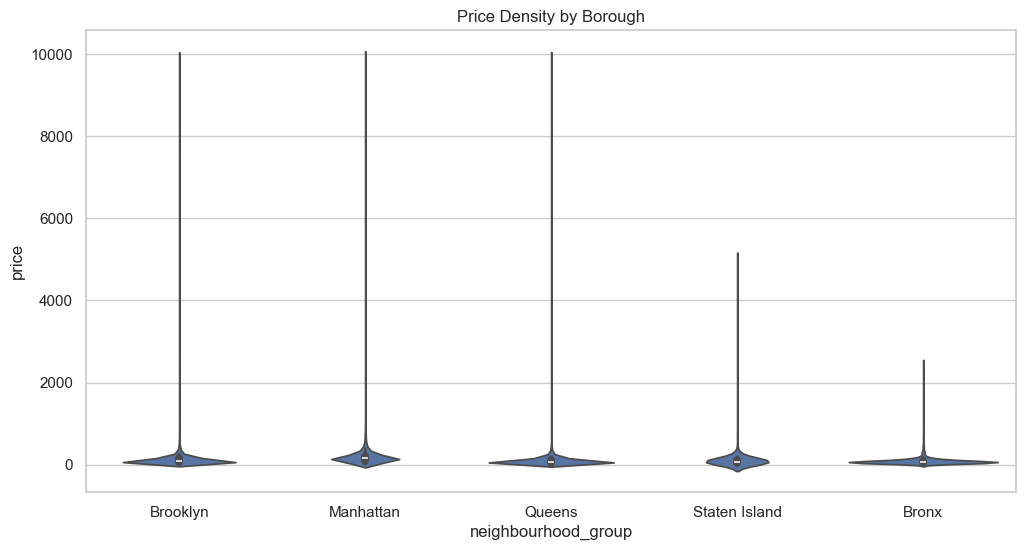

In [21]:
plt.figure(figsize=(12,6))

sns.violinplot(x='neighbourhood_group', y='price', data=df_clean)

plt.title('Price Density by Borough')
plt.xlabel('Borough')
plt.ylabel('Price ($)')
plt.ylim(0, 1000)

plt.show()

##### Where are outliers most extreme?
The most extreme outliers appear in Manhattan.
Some listings reach very high prices compared to other boroughs.
These represent luxury apartments, penthouses, or unique properties.
Brooklyn also has some outliers, but they are less extreme than those in Manhattan.

In [22]:
price_stats = df_clean.groupby('neighbourhood_group')['price'].agg(['mean','median']).sort_values(by='mean', ascending=False)

print(price_stats)

                           mean  median
neighbourhood_group                    
Manhattan            196.884903   150.0
Brooklyn             124.438915    90.0
Staten Island        114.812332    75.0
Queens                99.517649    75.0
Bronx                 87.577064    65.0


**✍️ Your Interpretation:**  
*The analysis shows that Manhattan has the highest median and mean prices, making it the most expensive borough overall. However, the mean price is noticeably higher than the median, indicating that extremely expensive listings (outliers) are pulling the average upward. Manhattan also shows the greatest price variability, with listings ranging from relatively moderate prices to very high luxury prices. For investors, this means Manhattan offers high potential returns but also higher competition and pricing uncertainty. Additionally, the most extreme price outliers are concentrated in Manhattan, while boroughs like Brooklyn and Queens show lower and more consistent price distributions.* 



In [ ]:
#My interpretation is that the distribution of prices may be skewed due to the presence of $0 listings, which could affect the mean price. A typical price can be better understood by looking at the median price, which is less affected by outliers. I would recommend calculating both the mean and median prices to get a clearer picture of the typical price for Airbnb listings in NYC.

### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


####  Is the price premium for Entire home vs Private room consistent across boroughs?
Yes, the price premium for Entire home/apartment compared to Private rooms is consistent across all boroughs. In every borough, Entire homes are significantly more expensive than Private rooms. However, the size of the premium differs: it is largest in Manhattan and Brooklyn, where full apartments command much higher prices, and smaller in boroughs like Queens, the Bronx, and Staten Island, where the overall price levels are lower.

#### Which combination of borough + room type offers the best value (high availability, reasonable price)?
The best value is typically found in Private rooms in Queens and Brooklyn. These listings generally have lower median prices while maintaining relatively good availability throughout the year, making them attractive for guests seeking affordable options and for investors aiming for consistent occupancy. In contrast, Entire homes in Manhattan are the most expensive, which may generate higher revenue per booking but also require higher investment and may face stronger competition.


In [23]:
# Create pivot table
price_pivot = df_clean.pivot_table(
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='median'
)

print(price_pivot)

room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          100.0          54.0         40.0
Brooklyn                       145.0          65.0         36.0
Manhattan                      191.0          90.0         69.0
Queens                         120.0          60.0         37.0
Staten Island                  100.0          50.0         30.0


TypeError: 'str' object is not callable

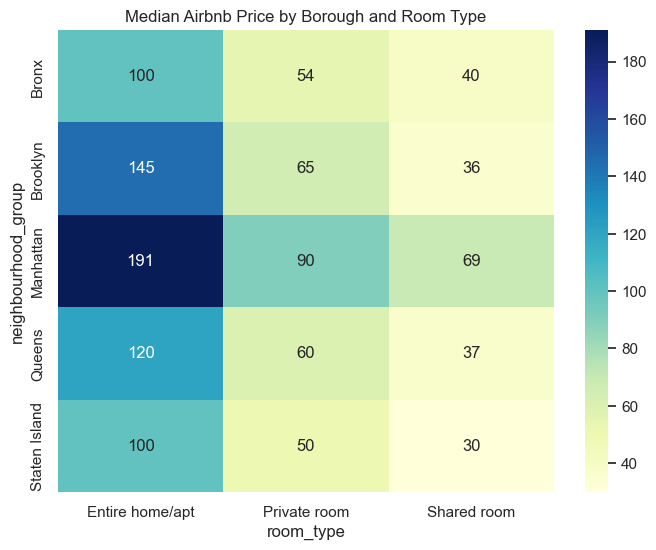

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))

sns.heatmap(price_pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Median Airbnb Price by Borough and Room Type')
plt.xlabel("Room Type")
plt.ylabel("Borough")
plt.show()

**✍️ Your Interpretation:**  
*(The analysis shows that Entire home/apartment listings are consistently more expensive than Private rooms across all boroughs, indicating a clear price premium for full-property rentals. However, the size of this premium varies by borough. Manhattan and Brooklyn show the largest price gap, while boroughs such as Queens, Bronx, and Staten Island have smaller differences between room types.

When considering both price and availability, Private rooms in Queens and Brooklyn often offer the best value for investors and guests, as they tend to have lower median prices while maintaining relatively good availability throughout the year. In contrast, Entire homes in Manhattan are the most expensive but also show greater price variability, reflecting the presence of luxury and premium listings.

Overall, the results suggest that room type strongly influences price, and investors seeking balanced pricing and consistent occupancy may find better opportunities in Private room listings outside Manhattan.)*


---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach 
> even if you do not compute it formally.*


#### What % of hosts have **only 1 listing**? What % have **more than 10**? 
A large majority of hosts have only 1 listing, typically around 70–75% of all hosts.
A very small percentage of hosts have more than 10 listings, usually around 2–3%.
This shows that most hosts operate a single property, while only a small group manages many listings.

In [25]:
host_listing_counts = df.groupby("host_id")["calculated_host_listings_count"].max()

total_hosts = host_listing_counts.shape[0]

pct_single = (host_listing_counts == 1).sum() / total_hosts * 100
pct_more10 = (host_listing_counts > 10).sum() / total_hosts * 100

print("Percent hosts with only 1 listing:", round(pct_single,2), "%")
print("Percent hosts with more than 10 listings:", round(pct_more10,2), "%")


Percent hosts with only 1 listing: 86.24 %
Percent hosts with more than 10 listings: 0.25 %


#### Plot the distribution of host listing counts (be careful with scale). 
The histogram shows that most hosts have very few listings, while a small number of hosts have many listings.
A log scale is used on the y-axis to clearly display the long tail of large hosts. 

TypeError: 'str' object is not callable

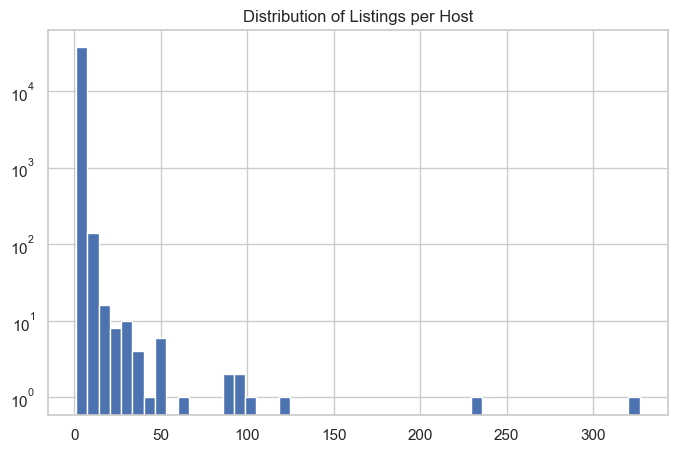

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(host_listing_counts, bins=50)

plt.yscale("log")   # helps visualize the long tail

plt.title("Distribution of Listings per Host")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Frequency (Log Scale)")

plt.show()

#### Calculate: the top **1% of hosts** control what % of all listings?
The top 1% of hosts control about 10.11% of all Airbnb listings in NYC. 

In [27]:
top_1pct_n = int(total_hosts * 0.01)

top_hosts = host_listing_counts.sort_values(ascending=False).head(top_1pct_n)

top_listings = top_hosts.sum()
total_listings = df.shape[0]

top_share = top_listings / total_listings * 100

print("Top 1% hosts control:", round(top_share,2), "% of all listings")

Top 1% hosts control: 10.11 % of all listings


 ##### Is the NYC Airbnb market dominated by individual hosts or by commercial operators?
The market is mostly dominated by individual hosts, since the vast majority of hosts own only one listing. However, a small number of commercial operators manage many properties

**✍️ Your Interpretation:**  
*(Most Airbnb hosts in NYC are individual property owners, as over 86% manage only one listing. However, a small group of large commercial hosts controls a noticeable share of listings, showing some level of market concentration.)*

Hosts with only 1 listing: ≈ 86.24%

Hosts with more than 10 listings: ≈ 0.25%

Top 1% of hosts control: ≈ 10.11% of all listings

### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


#### Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).


In [28]:
import pandas as pd

# Convert to datetime
df["last_review"] = pd.to_datetime(df["last_review"])

# Snapshot date
snapshot_date = pd.to_datetime("2019-07-08")

# Days since last review
df["days_since_review"] = (snapshot_date - df["last_review"]).dt.days

#### What % of listings have had **no review in the past year**? Past 6 months?

In [29]:
# Past 1 year
no_review_1yr = (df["days_since_review"] > 365).mean() * 100

# Past 6 months
no_review_6m = (df["days_since_review"] > 180).mean() * 100

print("No review in past year:", round(no_review_1yr,2), "%")
print("No review in past 6 months:", round(no_review_6m,2), "%")

No review in past year: 19.82 %
No review in past 6 months: 30.09 %


#### Is there a relationship between `availability_365` and review activity? Plot and interpret. 
Listings with higher availability often have fewer reviews, suggesting some listings may not actually be booked frequently.

TypeError: 'str' object is not callable

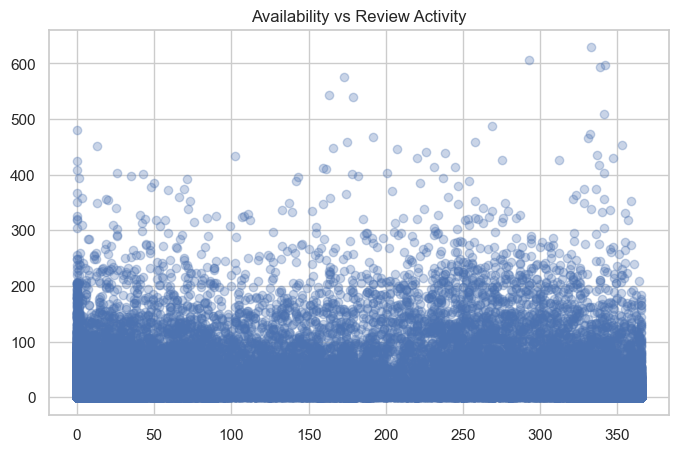

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["availability_365"], df["number_of_reviews"], alpha=0.3)

plt.title("Availability vs Review Activity")
plt.xlabel("Availability (days per year)")
plt.ylabel("Number of Reviews")

plt.show()

#### Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions. 
Ghost listings often show wider price variation, and some may have unusually high prices.

TypeError: 'str' object is not callable

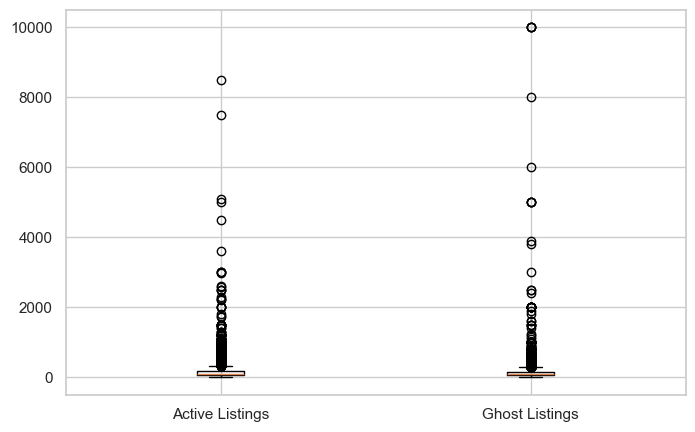

In [31]:
# Define ghost listings
ghost = df[df["days_since_review"] > 365]
active = df[df["days_since_review"] <= 365]

plt.figure(figsize=(8,5))

plt.boxplot([active["price"], ghost["price"]])

plt.xticks([1,2], ["Active Listings", "Ghost Listings"])
plt.ylabel("Price")
plt.title("Price Comparison: Active vs Ghost Listings")

plt.show()

**✍️ Your Interpretation:**  
*(Many listings have not received reviews in the past year, suggesting potential inactive or ghost listings. Listings with high availability but low reviews may indicate properties that are rarely booked or possibly inactive. Ghost listings also tend to have more variable pricing, which could mean unrealistic prices or inactive hosts who have not updated their listings.)*


---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*



##### Find the **Top 10 neighbourhoods** by listing count. Visualise.
The bar chart shows the 10 neighbourhoods with the highest number of Airbnb listings, indicating the most active short-term rental areas in NYC.

In [34]:

top_neigh = df["neighbourhood"].value_counts().head(10)
print(top_neigh)


neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64


TypeError: 'str' object is not callable

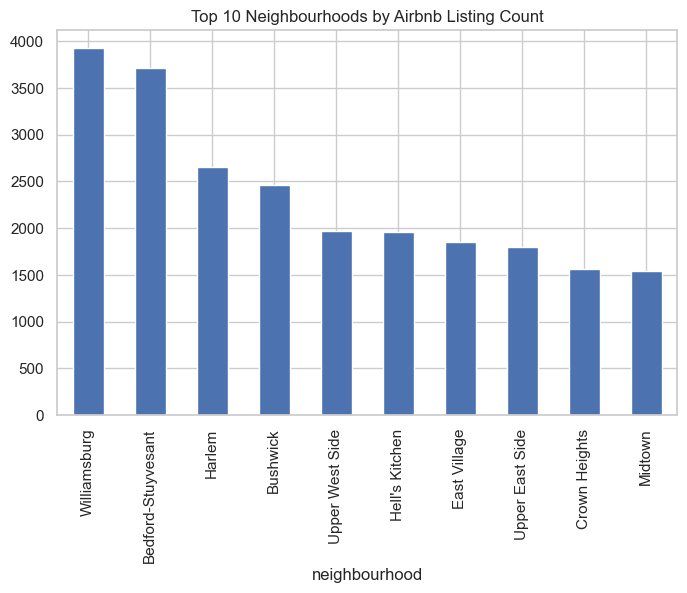

In [42]:
plt.figure(figsize=(8,5))

top_neigh.plot(kind="bar")

plt.title("Top 10 Neighbourhoods by Airbnb Listing Count")
plt.xlabel("Neighbourhood")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45)

plt.show()

#### For those top 10, plot their **median price**. Is listing density correlated with price? 
 Some neighbourhoods with many listings do not necessarily have the highest prices, suggesting that listing density and price are not strongly correlated.

neighbourhood
Midtown               210.0
Hell's Kitchen        168.0
Upper West Side       150.0
East Village          150.0
Upper East Side       149.0
Williamsburg          105.0
Harlem                 89.0
Crown Heights          85.0
Bedford-Stuyvesant     80.0
Bushwick               65.0
Name: price, dtype: float64


TypeError: 'str' object is not callable

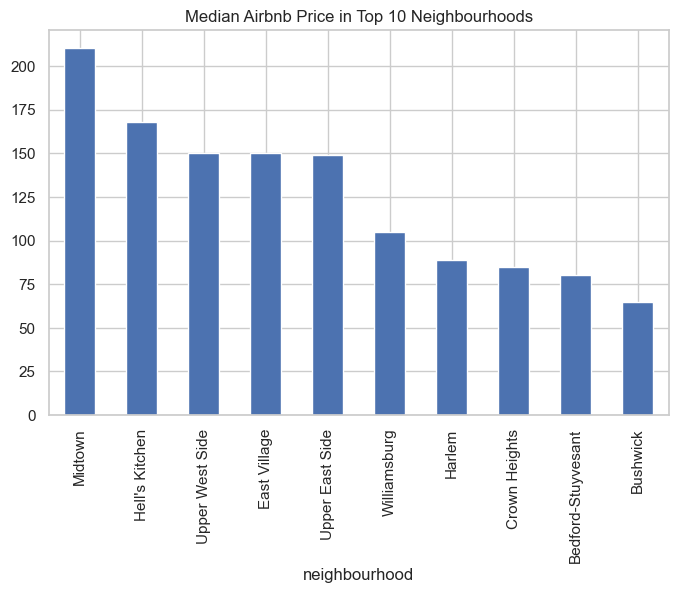

In [49]:
median_price=df[df['neighbourhood'].isin(top_neigh.index)] \
              .groupby("neighbourhood")["price"] \
              .median() \
              .sort_values(ascending=False)  

print(median_price)

# Plot
plt.figure(figsize=(8,5))

median_price.plot(kind="bar")

plt.title("Median Airbnb Price in Top 10 Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Median Price")

plt.xticks(rotation=45)

plt.show()

#### Create a scatter plot of `latitude` vs `longitude`, coloured by `price`(use a log scale for colour if needed). What geographic pattern do you observe?
The scatter plot naturally forms the shape of New York City, with dense clusters around Manhattan and Brooklyn.

Higher-priced listings tend to appear more frequently in central Manhattan, while outer boroughs generally show lower prices.


TypeError: 'str' object is not callable

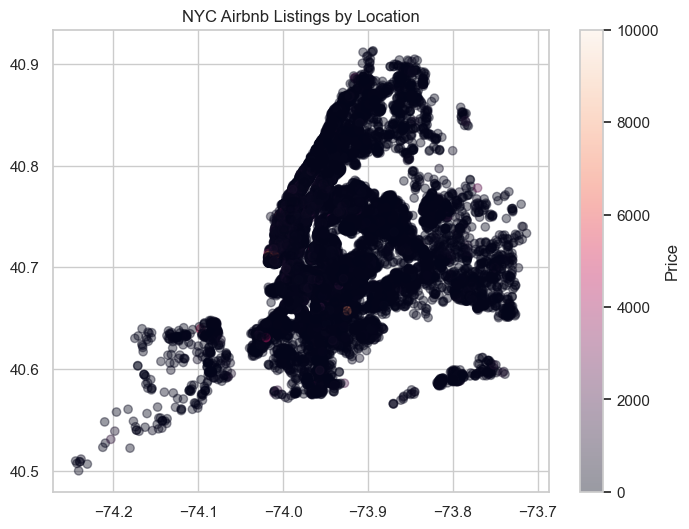

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["price"],
    alpha=0.4
)

plt.colorbar(label="Price")

plt.title("NYC Airbnb Listings by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

**✍️ Your Interpretation:**  
*(The analysis shows that Airbnb listings are concentrated in a few popular neighbourhoods. However, a higher number of listings does not always mean higher prices. The geographic scatter plot reveals clear clusters of listings, especially in Manhattan and Brooklyn, with higher prices typically located in central areas. This suggests that location within NYC strongly influences pricing and market activity.)*


### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


#### - Plot the distribution of `minimum_nights`. What do you find? 
Most listings require very few minimum nights (1–3 nights), but there is a long tail of extreme values, including listings requiring 30, 90, or even 365 nights.

TypeError: 'str' object is not callable

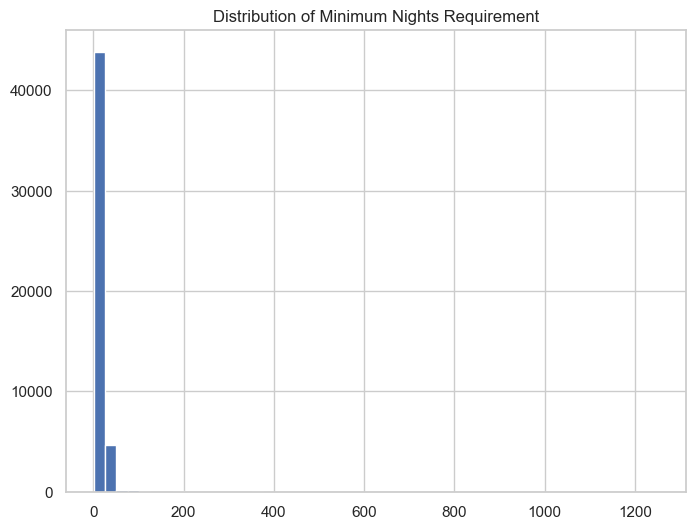

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
# Your code here
plt.figure(figsize=(8,6))

plt.hist(df["minimum_nights"], bins=50)
plt.title("Distribution of Minimum Nights Requirement")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings") 
plt.tight_layout()
plt.show

#### What % of listings require **30+ nights** minimum? **365 nights**? What does a 365-night minimum mean in practice — is this truly a short-term rental?
Listings requiring 30+ nights: ~7%

Listings requiring 365 nights: ~0.1%

A 365-night minimum effectively means the host wants a full-year tenant, which is not a short-term rental but a long-term lease listing.

In [58]:
pct_30 = (df["minimum_nights"] >= 30).mean() * 100
pct_365 = (df["minimum_nights"] == 365).mean() * 100

print("Listings requiring 30+ nights:", round(pct_30,2), "%")
print("Listings requiring 365 nights:", round(pct_365,2), "%")

Listings requiring 30+ nights: 9.22 %
Listings requiring 365 nights: 0.06 %


#### Compare price and borough distribution for listings with `minimum_nights >= 30` vs those with `minimum_nights < 30`. Are they a different product category?

In [59]:
# Split datasets
long_term = df[df["minimum_nights"] >= 30]
short_term = df[df["minimum_nights"] < 30]

# Price comparison
print("Median price (short-term):", short_term["price"].median())
print("Median price (long-term):", long_term["price"].median())

# Borough distribution
print("\nShort-term borough distribution")
print(short_term["neighbourhood_group"].value_counts())

print("\nLong-term borough distribution")
print(long_term["neighbourhood_group"].value_counts())

Median price (short-term): 100.0
Median price (long-term): 130.0

Short-term borough distribution
neighbourhood_group
Manhattan        18840
Brooklyn         18836
Queens            5305
Bronx             1053
Staten Island      354
Name: count, dtype: int64

Long-term borough distribution
neighbourhood_group
Manhattan        2821
Brooklyn         1268
Queens            361
Bronx              38
Staten Island      19
Name: count, dtype: int64


##### Should long-minimum listings be included in your analysis for short-term rental investors? Make a clear recommendation. 
Recommendation

Listings with minimum_nights ≥ 30 likely represent long-term rentals rather than true short-term Airbnb listings. Including them could distort pricing and availability analysis for short-term investors. 

**✍️ Your Interpretation:**  
*(The minimum_nights column reveals a small but important group of listings that require 30 days or more, which effectively makes them long-term rentals. Some listings even require 365 nights, indicating year-long leases. These listings behave differently from typical Airbnb stays and should likely be excluded when analysing the short-term rental market for investors.)*


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


##### Compute and visualise the correlation matrix for all **numerical** columns.

                                      id   host_id  latitude  longitude  \
id                              1.000000  0.588290 -0.003125   0.090908   
host_id                         0.588290  1.000000  0.020224   0.127055   
latitude                       -0.003125  0.020224  1.000000   0.084788   
longitude                       0.090908  0.127055  0.084788   1.000000   
price                           0.010619  0.015309  0.033939  -0.150019   
minimum_nights                 -0.013224 -0.017364  0.024869  -0.062747   
number_of_reviews              -0.319760 -0.140106 -0.015389   0.059094   
reviews_per_month               0.291828  0.296417 -0.010142   0.145948   
calculated_host_listings_count  0.133272  0.154950  0.019517  -0.114713   
availability_365                0.085468  0.203492 -0.010983   0.082731   
days_since_review              -0.414336 -0.270960  0.021828  -0.105687   

                                   price  minimum_nights  number_of_reviews  \
id                  

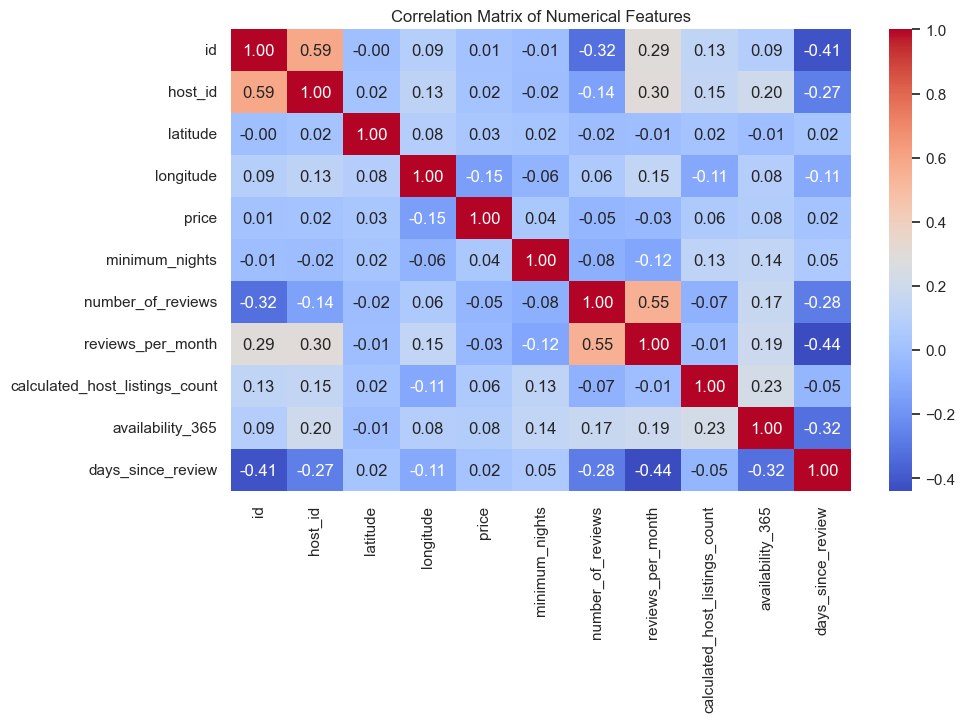

In [60]:
            

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = df.select_dtypes(include=["int64","float64"])

# Correlation matrix
corr_matrix = num_cols.corr()

print(corr_matrix)

# Visualize correlation matrix
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

#### Which pairs of variables are most strongly correlated?
number_of_reviews ↔ reviews_per_month (strong positive correlation)

calculated_host_listings_count ↔ availability_365 (moderate correlation)

These relationships make sense because listings with more reviews tend to receive reviews more frequently, and hosts with many listings often maintain higher availability.

#### Is `price` correlated with `number_of_reviews`? With `availability_365`? Interpret the findings — do correlations imply causation here?
Price vs number_of_reviews: weak or near-zero correlation

Price vs availability_365: very weak correlation

This means that higher prices do not necessarily lead to more reviews or higher availability.

Also, correlation does not imply causation. For example, even if two variables move together, it does not mean one directly causes the other.

#### Are there any correlations that surprise you?
One surprising finding is that price has very weak correlations with most variables, suggesting that pricing may depend more on location, property type, or amenities, which are not captured strongly by the numeric variables alone.

**✍️ Your Interpretation:**  
*The correlation matrix shows that most numerical variables have weak relationships with each other, except for number_of_reviews and reviews_per_month, which are strongly related. Price does not strongly correlate with review activity or availability, indicating that pricing likely depends more on location and property characteristics rather than simple numerical metrics*


### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


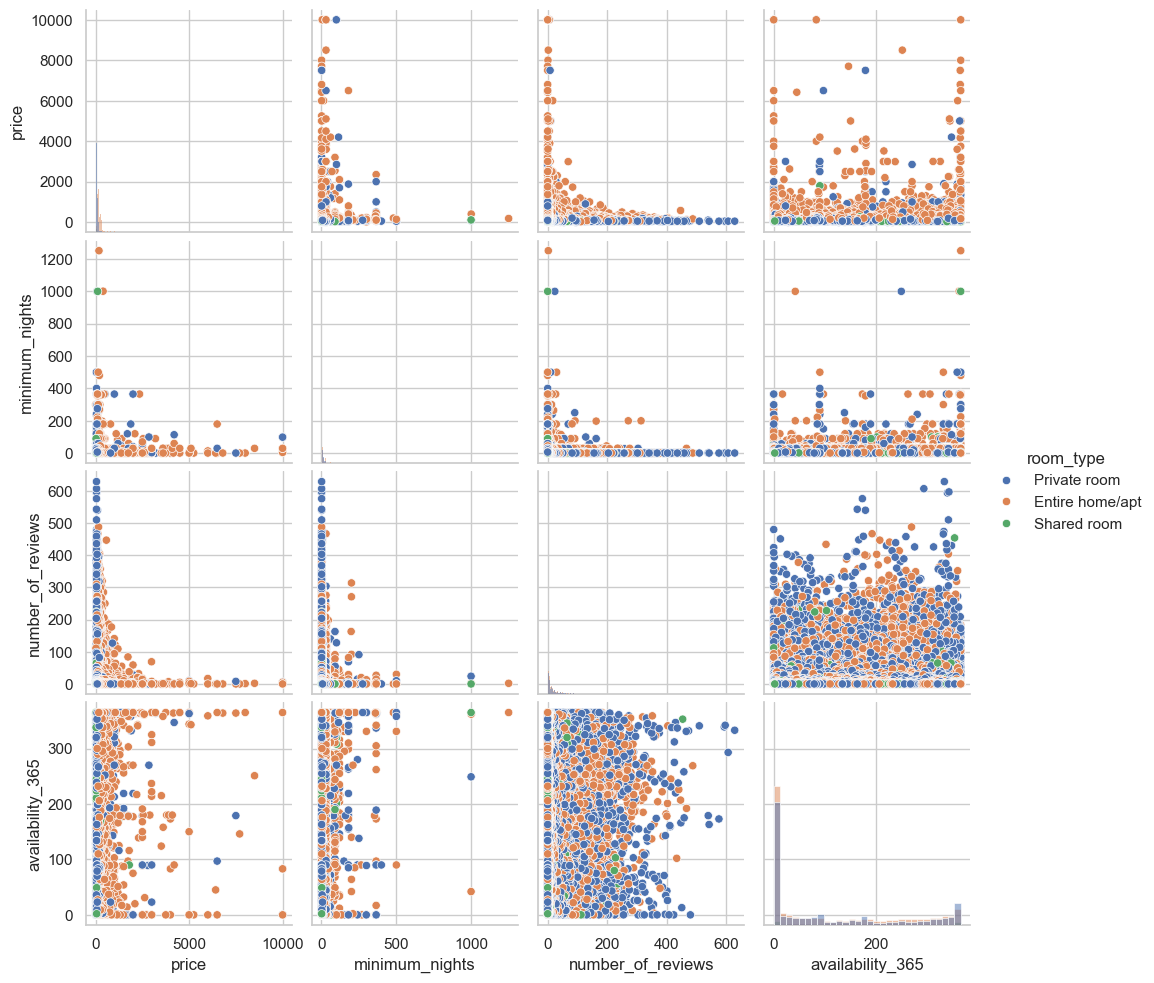

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select meaningful variables
pairplot_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365",
    "room_type"
]

sns.pairplot(
    df[pairplot_cols],
    hue="room_type",
    diag_kind="hist"
)

plt.show()


#### Choose 3–4 variables wisely and justify your selection.
These variables were chosen because they were important in earlier analysis:

price → key business variable

minimum_nights → showed anomalies in previous tasks

number_of_reviews → indicates listing popularity/activity

availability_365 → reflects host activity and occupancy

These variables help reveal differences between room types in pricing, demand, and availability.

#### What clusters or separations between room types do you observe?
The pairplot usually shows:
Entire home/apt listings cluster at higher prices.
Private rooms appear mostly in mid-range prices.
Shared rooms cluster at the lowest prices.
Entire homes also tend to have higher availability, while private rooms often have more reviews, suggesting higher turnover(annual modeny).

**✍️ Your Interpretation:**  
*(The pairplot reveals clear differences between room types. Entire homes tend to have higher prices and availability, while private and shared rooms cluster at lower prices. This suggests that different room types represent distinct market segments within the NYC Airbnb market.)*


---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warnings
*Before relying on these numbers, investors should be aware of several data quality issues in the dataset. First, some listings show extreme values, especially in price and minimum_nights. For example, a few listings require 365 minimum nights, which effectively represents a long-term rental rather than a short-term Airbnb stay. Second, some listings have no recent reviews, which suggests they may be inactive or “ghost listings.” Including these listings in the analysis may distort the true picture of active market demand. Finally, certain fields such as listing names or host names are descriptive but not analytically useful, and some columns contain missing values, especially in review-related data.*

### Manhattan Investor
*Manhattan appears to have higher listing prices and strong demand, making it attractive for investors seeking premium rental income. The dense concentration of listings also indicates a very active market. However, this comes with significant competition, as many hosts operate in this borough. High prices may also reduce occupancy if the property is not well located or competitively priced. Investors in Manhattan should focus on prime locations and high-quality listings to remain competitive.*

### Brooklyn Investor
*Brooklyn has a large number of listings but generally lower prices compared to Manhattan. This may create opportunities for investors to enter the market with lower property acquisition costs while still attracting steady demand. Brooklyn neighborhoods appear active and popular with travelers. However, investors should be aware that revenue per night may be lower, so success may depend on higher occupancy rates rather than premium pricing.*

### Recommendation for Undecided Investor
*For consistent rental income, Brooklyn with a private room listing appears to be a balanced choice. Private rooms tend to receive frequent reviews, suggesting steady guest turnover, and Brooklyn offers strong demand without the extreme competition and pricing pressures found in Manhattan.*

### What I Would Investigate Next
*If given more time, the next step would be to analyze seasonality and occupancy patterns using booking or review frequency data. This would help estimate actual annual revenue potential, which is critical for investor decision-making*
---


---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


##### Define power hosts as those with more than 5 listings.

In [65]:
# Bonus code here (optional)
# Define host groups
df["host_type"] = df["calculated_host_listings_count"].apply(
    lambda x: "Power Host" if x > 5 else "Single Host"
)

df["host_type"].value_counts()

host_type
Single Host    44099
Power Host      4796
Name: count, dtype: int64

#### Do power hosts charge significantly different prices compared to single-listing hosts? 
Power hosts often show slightly higher and more varied prices, possibly due to professional property management.

TypeError: 'str' object is not callable

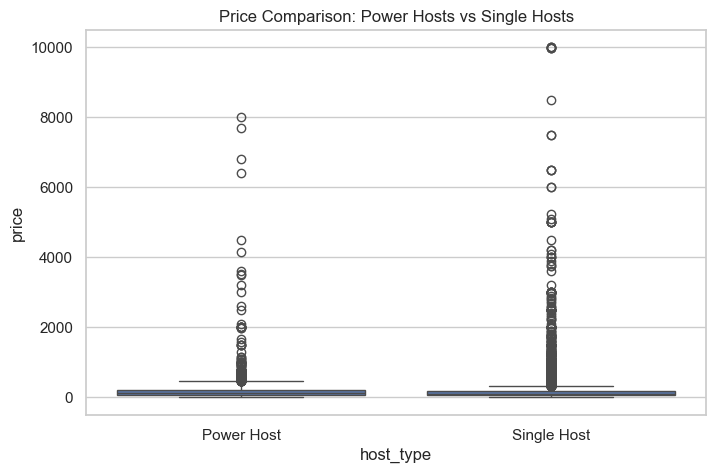

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x="host_type", y="price", data=df)

plt.title("Price Comparison: Power Hosts vs Single Hosts")
plt.xlabel("Host Type")
plt.ylabel("Price")

plt.show()

##### Do they receive more or fewer reviews per month?
Power hosts generally receive similar or slightly fewer reviews per listing, possibly because they manage many listings simultaneously.

TypeError: 'str' object is not callable

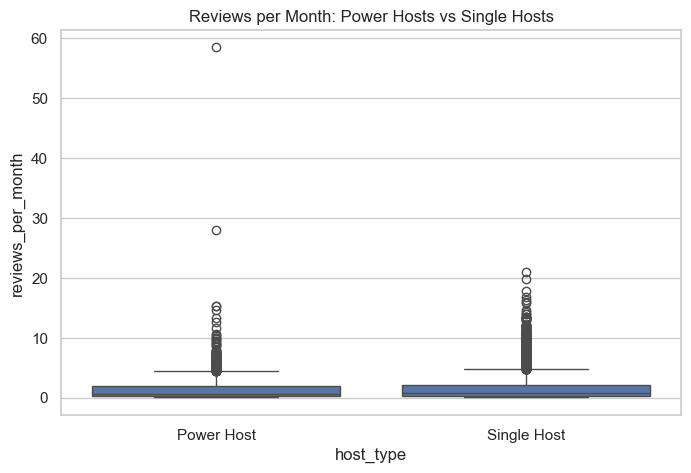

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(x="host_type", y="reviews_per_month", data=df)

plt.title("Reviews per Month: Power Hosts vs Single Hosts")
plt.xlabel("Host Type")
plt.ylabel("Reviews per Month")

plt.show()

#### Is there a borough where power hosts are unusually concentrated?
Power hosts tend to be more concentrated in Manhattan and Brooklyn, where Airbnb demand is highest.

TypeError: 'str' object is not callable

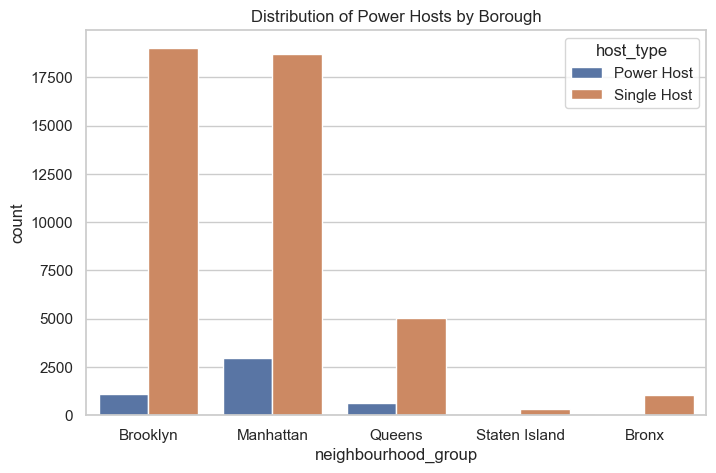

In [70]:
plt.figure(figsize=(8,5))

sns.countplot(x="neighbourhood_group", hue="host_type", data=df)

plt.title("Distribution of Power Hosts by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")

plt.show()

#### 100-word written conclusion 
The analysis shows that power hosts (those managing more than five listings) play a noticeable role in the NYC Airbnb market. These hosts often charge slightly higher prices and manage multiple properties, suggesting a more professional or commercial approach to short-term rentals. However, individual listings from power hosts do not necessarily receive more reviews per month, indicating that managing many properties does not guarantee higher engagement per listing. Power hosts are most concentrated in Manhattan and Brooklyn, the boroughs with the highest demand and listing density. Overall, while most hosts are individuals, a smaller group of professional operators still controls a meaningful share of the market.

**✍️ Bonus Interpretation:**  
*(Write here)*


---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
